# **Análise Exploratória de Dados (EDA) 📊**

In [14]:
import pandas as pd

df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')


# 📋 1. Visão Geral da Base

Nesta etapa, será realizada uma análise inicial do conjunto de dados para compreender sua estrutura, dimensão e organização das variáveis.

In [15]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

df.head()

Linhas: 7043
Colunas: 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [16]:
# Tipos de dados
df.info()

# Contagem por tipo
df.dtypes.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

str        23
int64       6
float64     3
object      1
Name: count, dtype: int64

In [17]:
# Valores nulos
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

nulls_df = pd.DataFrame({
    'qtd_nulos': nulls,
    'percentual_nulos': nulls_percent
})

nulls_df[nulls_df['qtd_nulos'] > 0]

,qtd_nulos,percentual_nulos
Churn Reason,5174,73.463013


In [18]:
# Valores únicos
df.nunique().sort_values(ascending=False)

CustomerID           7043
Total Charges        6531
CLTV                 3438
Lat Long             1652
Latitude             1652
Zip Code             1652
Longitude            1651
Monthly Charges      1585
City                 1129
Churn Score            85
Tenure Months          73
Churn Reason           20
Payment Method          4
Online Backup           3
Online Security         3
Multiple Lines          3
Internet Service        3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Senior Citizen          2
Partner                 2
Dependents              2
Gender                  2
Paperless Billing       2
Churn Label             2
Phone Service           2
Churn Value             2
Count                   1
Country                 1
State                   1
dtype: int64

💡 **Observação:**

A base de dados possui **7043 registros** e **33 variáveis**, representando um volume adequado para análises exploratórias e modelagem preditiva.

A inspeção inicial indica que o conjunto contém informações de diferentes naturezas, incluindo dados **demográficos (gênero, localização)**, **contratuais (tipo de contrato, serviços contratados)** e **financeiros (cobrança mensal e total)**, além de variáveis diretamente relacionadas ao churn.

Em relação aos tipos de dados, observa-se uma predominância de variáveis categóricas (strings), acompanhadas por variáveis numéricas inteiras e contínuas, o que permite uma análise diversificada entre perfis de clientes e comportamentos quantitativos.

A análise de valores ausentes mostra que a base está praticamente completa, com exceção da coluna **"Churn Reason"**, que apresenta aproximadamente **73% de valores nulos**. No entanto, esse comportamento é esperado, pois o motivo de churn tende a existir apenas para clientes que efetivamente cancelaram o serviço, não representando necessariamente um problema de qualidade dos dados.

A avaliação da cardinalidade revela a presença de colunas com alta quantidade de valores únicos, como **CustomerID**, além de variáveis geográficas como **Latitude, Longitude e Zip Code**, que podem não ser relevantes para modelagem preditiva inicial. Também são observadas variáveis com baixa cardinalidade, indicando possíveis categorias importantes para segmentação de clientes.

De forma geral, a base apresenta boa qualidade, diversidade de variáveis e estrutura adequada para análises exploratórias e construção de modelos supervisionados de churn.

# 🎯 2. Análise da Variável Alvo

Nesta etapa, será analisada a distribuição da variável de churn, com o objetivo de identificar a proporção de clientes que permaneceram e daqueles que cancelaram o serviço.

In [19]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
(df['Churn Label'].value_counts(normalize=True) * 100).round(2)

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

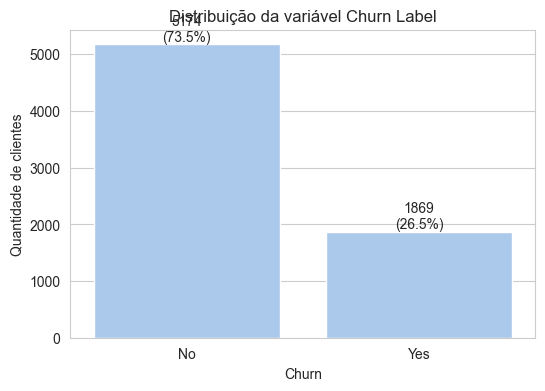

In [26]:
sns.set_palette("pastel")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Churn Label', order=['No', 'Yes'])

total = len(df)

for p in ax.patches:
    altura = p.get_height()
    percentual = 100 * altura / total
    ax.annotate(f'{int(altura)}\n({percentual:.1f}%)',
                (p.get_x() + p.get_width()/2, altura),
                ha='center', va='bottom')

plt.title('Distribuição da variável Churn Label')
plt.xlabel('Churn')
plt.ylabel('Quantidade de clientes')
plt.show()

💡 **Observação:**

A análise da variável alvo mostra que **5174 clientes (73,46%)** permaneceram na empresa, enquanto **1869 clientes (26,54%)** realizaram churn.

Essa distribuição indica que a base apresenta **desbalanceamento entre as classes**, com predominância de clientes que não cancelaram o serviço. Esse aspecto é importante, pois pode influenciar etapas futuras de modelagem, exigindo atenção especial na escolha de métricas e possíveis técnicas de balanceamento.

Ainda assim, a proporção de clientes com churn é significativa, o que permite investigar padrões relevantes associados ao cancelamento e explorar fatores que possam influenciar esse comportamento.

# 📈 3. Análise das Variáveis Numéricas

Nesta etapa, serão analisadas as principais variáveis numéricas da base, com o objetivo de compreender sua distribuição e identificar possíveis diferenças entre clientes que realizaram churn e aqueles que permaneceram na empresa.

In [27]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

df[num_cols].describe()

,Tenure Months,Monthly Charges,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,58.699418,4400.295755
std,24.559481,30.090047,21.525131,1183.057152
min,0.000000,18.250000,5.000000,2003.000000
25%,9.000000,35.500000,40.000000,3469.000000
50%,29.000000,70.350000,61.000000,4527.000000
75%,55.000000,89.850000,75.000000,5380.500000
max,72.000000,118.750000,100.000000,6500.000000


In [32]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [33]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [58]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
count,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441,58.699418,4400.295755
std,24.559481,30.090047,2266.771362,21.525131,1183.057152
min,0.000000,18.250000,18.800000,5.000000,2003.000000
25%,9.000000,35.500000,401.450000,40.000000,3469.000000
50%,29.000000,70.350000,1397.475000,61.000000,4527.000000
75%,55.000000,89.850000,3794.737500,75.000000,5380.500000
max,72.000000,118.750000,8684.800000,100.000000,6500.000000


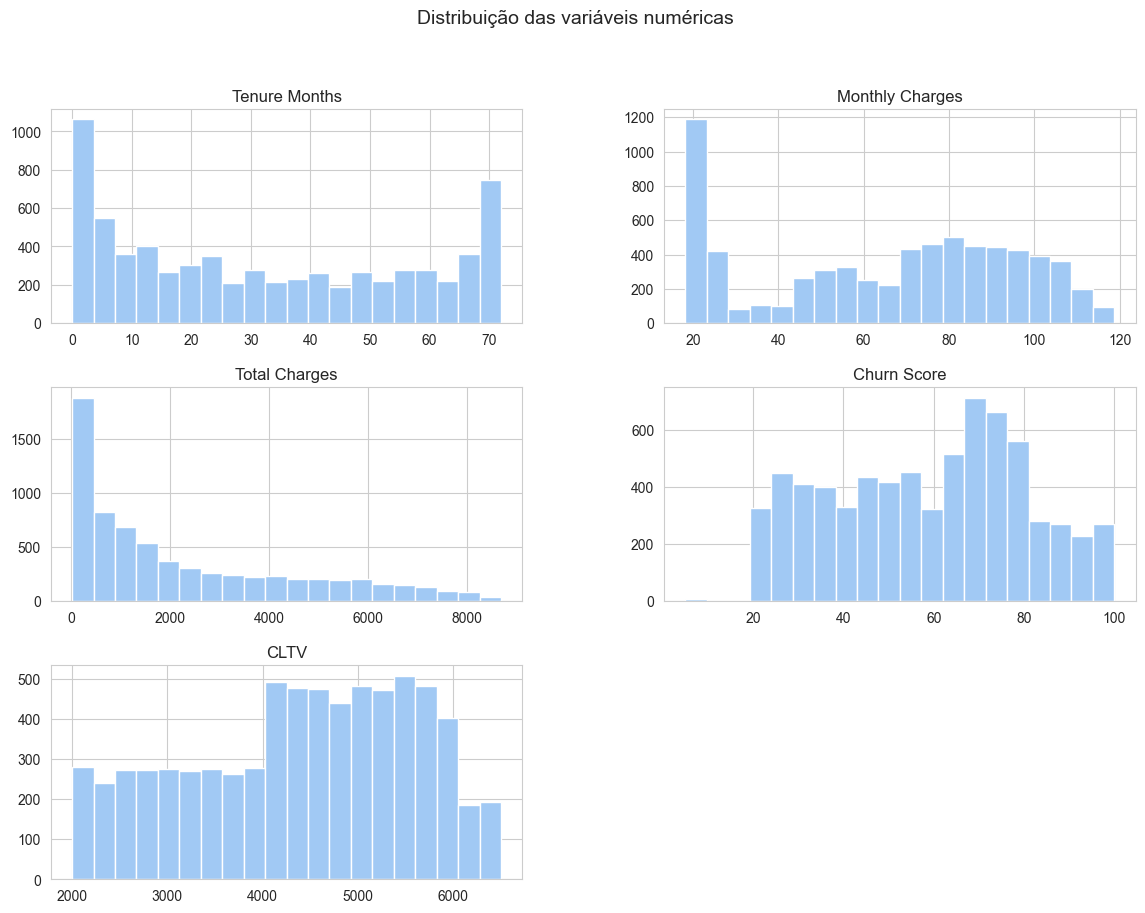

In [59]:
sns.set_palette("pastel")
df[num_cols].hist(figsize=(14,10), bins=20)
plt.suptitle('Distribuição das variáveis numéricas', fontsize=14)
plt.show()

C:\Users\necca\AppData\Local\Temp\ipykernel_4764\3424842084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


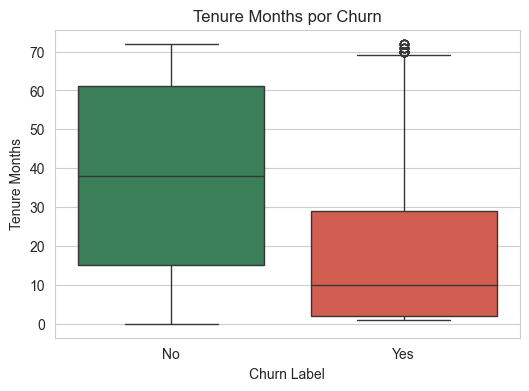

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Churn Label',
    y='Tenure Months',
    order=['No', 'Yes'],
    palette={'No': '#2E8B57', 'Yes': '#E74C3C'}
)
plt.title('Tenure Months por Churn')
plt.show()

C:\Users\necca\AppData\Local\Temp\ipykernel_4764\3761503330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


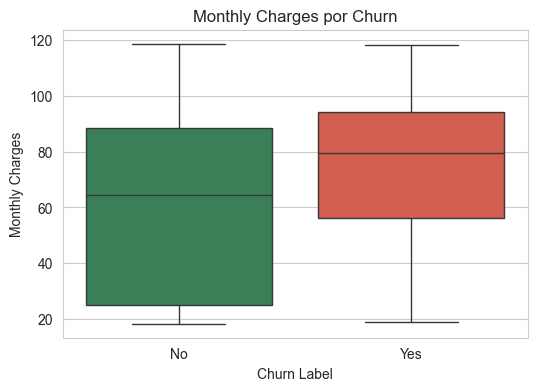

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Churn Label',
    y='Monthly Charges',
    order=['No', 'Yes'],
    palette={'No': '#2E8B57', 'Yes': '#E74C3C'}
)
plt.title('Monthly Charges por Churn')
plt.show()

C:\Users\necca\AppData\Local\Temp\ipykernel_4764\2910348882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


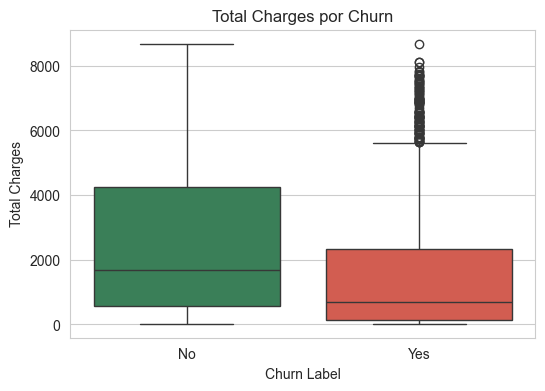

In [62]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Churn Label',
    y='Total Charges',
    order=['No', 'Yes'],
    palette={'No': '#2E8B57', 'Yes': '#E74C3C'}
)
plt.title('Total Charges por Churn')
plt.show()

💡 **Observação:**

A análise das variáveis numéricas mostra comportamentos distintos entre os clientes que permaneceram na empresa e aqueles que realizaram churn.

A variável **Tenure Months** apresenta uma diferença bastante evidente entre os grupos. Clientes que não realizaram churn possuem, em geral, maior tempo de permanência, enquanto os clientes que cancelaram tendem a concentrar-se em períodos mais curtos de vínculo com a empresa. Esse padrão sugere que o churn ocorre com maior frequência entre clientes mais recentes.

Em relação à variável **Monthly Charges**, observa-se que os clientes que realizaram churn apresentam, em média, cobranças mensais mais elevadas do que os clientes que permaneceram. Esse comportamento pode indicar que valores mensais mais altos estão associados a uma maior probabilidade de cancelamento.

Já a variável **Total Charges** apresenta valores mais altos entre os clientes que não realizaram churn, o que é coerente com o maior tempo de permanência desses clientes na empresa. Como o valor total acumulado depende da duração do vínculo, clientes mais antigos tendem naturalmente a apresentar cobranças totais maiores. Além disso, foram observados outliers entre os clientes com churn, indicando a existência de alguns casos com alta cobrança acumulada mesmo entre aqueles que cancelaram.

Os histogramas também mostram distribuições heterogêneas entre as variáveis, com destaque para a concentração de clientes em faixas menores de **Total Charges** e para a distribuição relativamente ampla de **Monthly Charges** e **CLTV**.

Durante essa etapa, foi identificado que a coluna **`Total Charges`** continha registros vazios representados por espaços em branco, o que impedia sua interpretação como variável numérica. Após a conversão para formato numérico, esses valores foram tratados como ausentes, permitindo a continuidade da análise de forma adequada.

De forma geral, as variáveis numéricas analisadas demonstram potencial explicativo relevante para o comportamento de churn, especialmente **Tenure Months**, **Monthly Charges** e **Total Charges**.

# 🧩 4. Análise das Variáveis Categóricas
Nesta etapa, serão analisadas algumas variáveis categóricas relevantes para identificar possíveis padrões de churn entre diferentes perfis de clientes.

## 📄 4.1 Tipo de Contrato
Nesta etapa, será analisada a relação entre o tipo de contrato do cliente e a ocorrência de churn.

In [63]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index') * 100
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


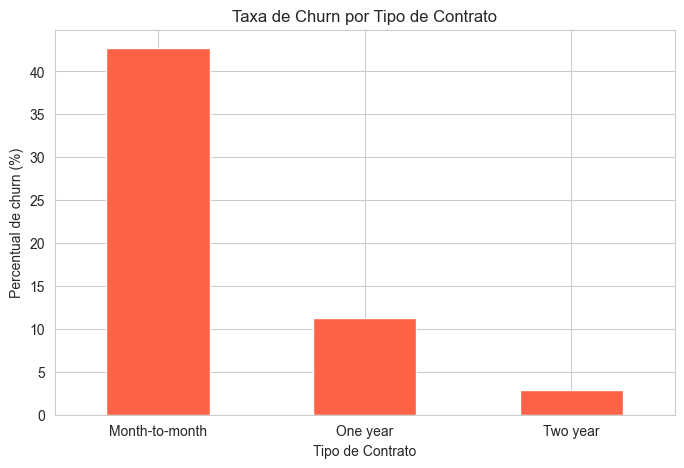

In [64]:
plt.figure(figsize=(8,5))
contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Percentual de churn (%)')
plt.xticks(rotation=0)
plt.show()

## 🌐 4.2 Serviço de Internet
Nesta etapa, será analisada a relação entre o tipo de serviço de internet contratado e a ocorrência de churn.

In [65]:
internet_churn = pd.crosstab(df['Internet Service'], df['Churn Label'], normalize='index') * 100
internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


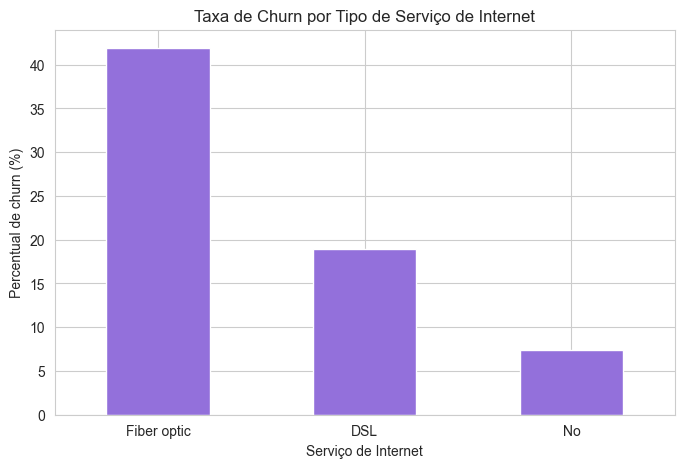

In [66]:
plt.figure(figsize=(8,5))
internet_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='mediumpurple')
plt.title('Taxa de Churn por Tipo de Serviço de Internet')
plt.xlabel('Serviço de Internet')
plt.ylabel('Percentual de churn (%)')
plt.xticks(rotation=0)
plt.show()

## 💳 4.3 Método de Pagamento
Nesta etapa, será analisada a relação entre o método de pagamento utilizado e a ocorrência de churn.

In [67]:
payment_churn = pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index') * 100
payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


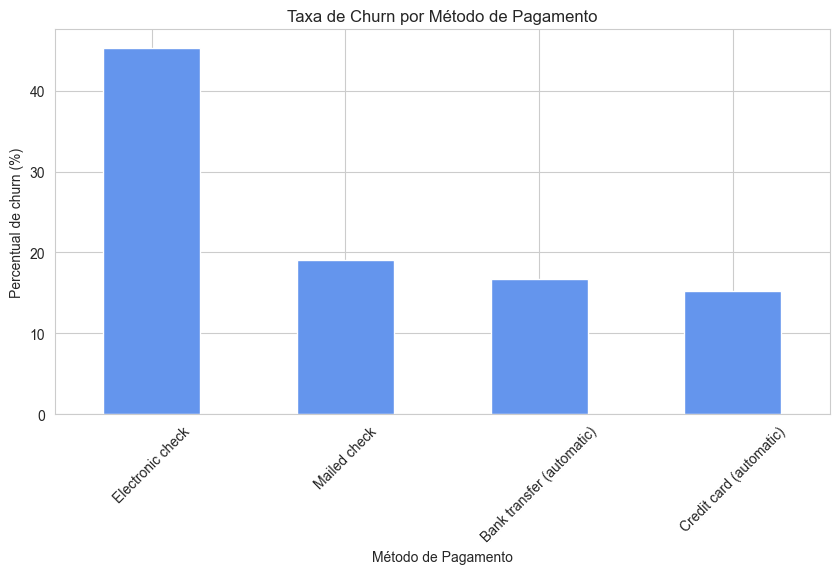

In [68]:
plt.figure(figsize=(10,5))
payment_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='cornflowerblue')
plt.title('Taxa de Churn por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Percentual de churn (%)')
plt.xticks(rotation=45)
plt.show()

## 🧾 4.4 Faturamento Digital
Nesta etapa, será analisada a relação entre o uso de faturamento digital e a ocorrência de churn.

In [69]:
paperless_churn = pd.crosstab(df['Paperless Billing'], df['Churn Label'], normalize='index') * 100
paperless_churn

Churn Label,No,Yes
Paperless Billing,,
No,83.669916,16.330084
Yes,66.434908,33.565092


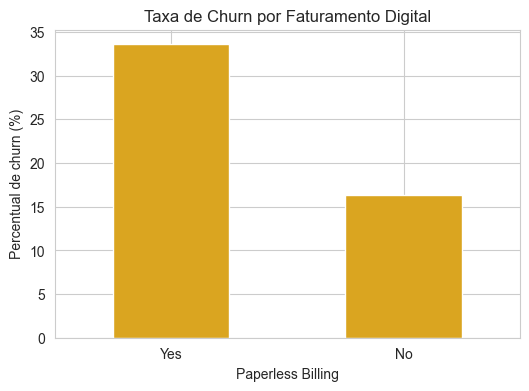

In [70]:
plt.figure(figsize=(6,4))
paperless_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='goldenrod')
plt.title('Taxa de Churn por Faturamento Digital')
plt.xlabel('Paperless Billing')
plt.ylabel('Percentual de churn (%)')
plt.xticks(rotation=0)
plt.show()

## 👵 4.5 Cliente Idoso
Nesta etapa, será analisada a relação entre o perfil de cliente idoso e a ocorrência de churn.

In [71]:
senior_churn = pd.crosstab(df['Senior Citizen'], df['Churn Label'], normalize='index') * 100
senior_churn

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


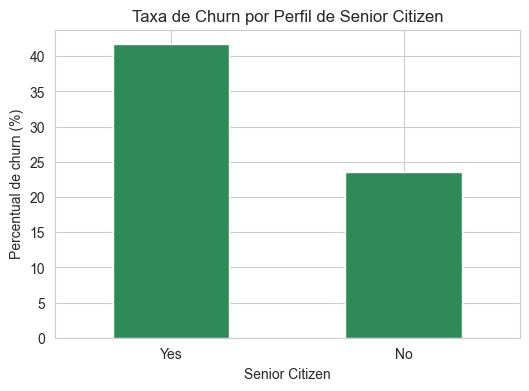

In [72]:
plt.figure(figsize=(6,4))
senior_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='seagreen')
plt.title('Taxa de Churn por Perfil de Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentual de churn (%)')
plt.xticks(rotation=0)
plt.show()

💡 **Observação:**

A análise das variáveis categóricas revelou padrões bastante relevantes associados ao churn dos clientes.

A variável **Contract** apresentou a relação mais evidente com churn. Clientes com contrato **month-to-month** possuem uma taxa de churn significativamente maior (aproximadamente 42%), enquanto contratos de **um ano** e **dois anos** apresentam taxas muito menores, chegando a menos de 3% para contratos de dois anos. Isso indica que contratos de longo prazo estão fortemente associados à retenção de clientes.

Em relação ao **Internet Service**, observa-se que clientes com **fibra óptica** apresentam maior taxa de churn (cerca de 42%) em comparação com clientes de **DSL** (aproximadamente 19%) e aqueles sem serviço de internet (cerca de 7%). Esse comportamento pode indicar maior insatisfação ou maior sensibilidade a preço entre clientes desse tipo de serviço.

A variável **Payment Method** também apresenta diferenças relevantes. Clientes que utilizam **electronic check** possuem a maior taxa de churn (aproximadamente 45%), enquanto métodos automáticos, como **bank transfer** e **credit card**, apresentam taxas significativamente menores. Isso sugere que métodos de pagamento automatizados podem estar associados a maior retenção.

Para **Paperless Billing**, clientes que utilizam faturamento digital apresentam maior taxa de churn (cerca de 33%) em comparação aos que não utilizam (aproximadamente 16%). Esse comportamento pode estar relacionado ao perfil mais digital desses clientes, possivelmente mais propensos a trocar de serviço.

Por fim, a variável **Senior Citizen** indica que clientes classificados como idosos apresentam uma taxa de churn mais elevada (aproximadamente 41%) em comparação com os demais clientes (cerca de 24%), sugerindo que esse grupo pode demandar maior atenção em estratégias de retenção.

De forma geral, as variáveis categóricas analisadas demonstram forte capacidade explicativa para o churn, com destaque para **tipo de contrato, método de pagamento e tipo de serviço de internet** como fatores mais relevantes.

# 🔗 5. Correlação e Relações entre Variáveis

Nesta etapa, serão analisadas as relações entre variáveis numéricas da base, buscando identificar padrões de associação e possíveis fatores relacionados ao churn.

In [73]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

## 🧮 5.1 Matriz de Correlação
Nesta etapa, será calculada a correlação entre as principais variáveis numéricas da base, com o objetivo de identificar relações lineares entre elas.

In [74]:
corr_matrix = df[num_cols].corr()
corr_matrix

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
Tenure Months,1.000000,0.247900,0.825880,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.651065,0.133754,0.098693
Total Charges,0.825880,0.651065,1.000000,-0.124312,0.341837
Churn Score,-0.224987,0.133754,-0.124312,1.000000,-0.079782
CLTV,0.396406,0.098693,0.341837,-0.079782,1.000000


## 🌡️ 5.2 Heatmap de Correlação
Nesta etapa, será representada graficamente a correlação entre as variáveis numéricas, facilitando a visualização das associações mais fortes.

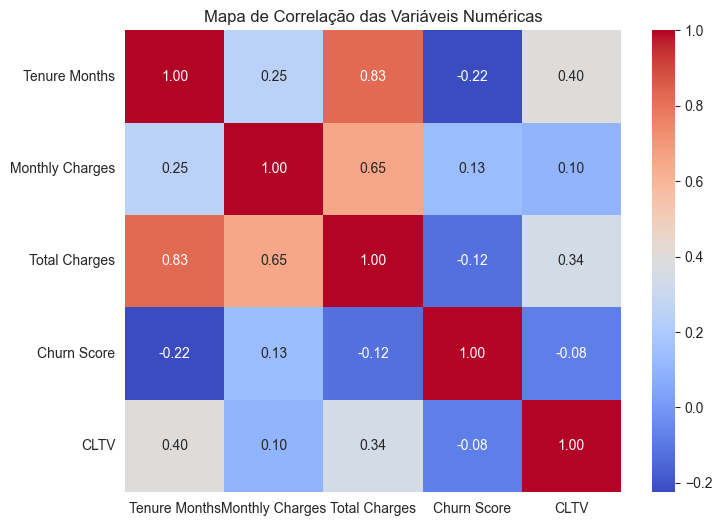

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlação das Variáveis Numéricas')
plt.show()

## 📍 5.3 Relação entre Cobrança Mensal e Cobrança Total
Nesta etapa, será analisada a relação entre cobrança mensal e cobrança total, considerando a separação entre clientes que realizaram churn e os que permaneceram.

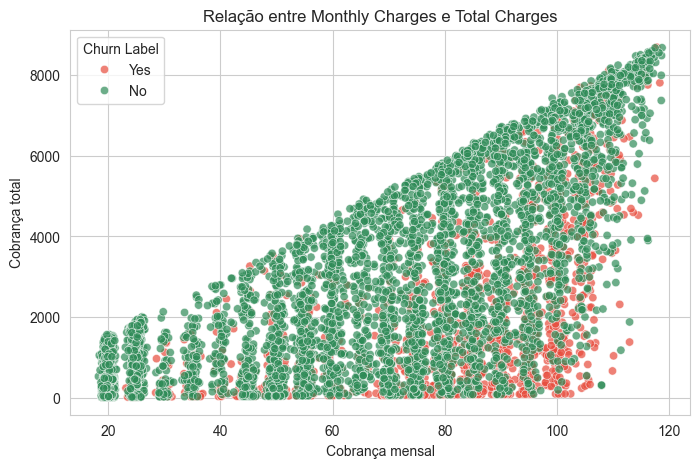

In [76]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Monthly Charges',
    y='Total Charges',
    hue='Churn Label',
    palette={'No': '#2E8B57', 'Yes': '#E74C3C'},
    alpha=0.7
)
plt.title('Relação entre Monthly Charges e Total Charges')
plt.xlabel('Cobrança mensal')
plt.ylabel('Cobrança total')
plt.show()

## ⏳ 5.4 Relação entre Tempo de Permanência e Cobrança Total
Nesta etapa, será analisada a relação entre o tempo de permanência do cliente e a cobrança total acumulada, considerando a variável de churn.

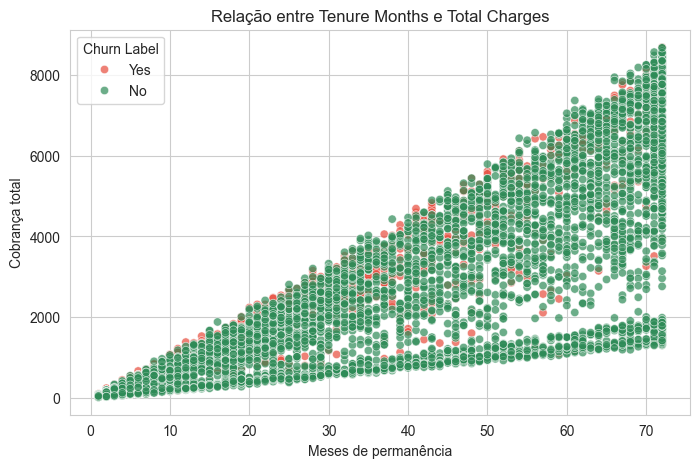

In [77]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Tenure Months',
    y='Total Charges',
    hue='Churn Label',
    palette={'No': '#2E8B57', 'Yes': '#E74C3C'},
    alpha=0.7
)
plt.title('Relação entre Tenure Months e Total Charges')
plt.xlabel('Meses de permanência')
plt.ylabel('Cobrança total')
plt.show()

💡 **Observação:**

A análise de correlação entre as variáveis numéricas revelou algumas relações importantes dentro da base.

A variável **Total Charges** apresenta forte correlação positiva com **Tenure Months** (0,83), indicando que quanto maior o tempo de permanência do cliente, maior tende a ser o valor total acumulado. Esse comportamento é esperado, já que a cobrança total está diretamente relacionada ao tempo de vínculo com a empresa.

Além disso, observa-se uma correlação moderada entre **Monthly Charges** e **Total Charges** (0,65), o que indica que valores mensais mais altos contribuem para um aumento mais rápido da cobrança total ao longo do tempo.

A variável **CLTV** também apresenta correlação positiva com **Tenure Months** (0,40) e **Total Charges** (0,34), sugerindo que clientes com maior tempo de permanência tendem a gerar maior valor ao longo do relacionamento com a empresa.

Em relação ao **Churn Score**, observa-se uma correlação negativa com **Tenure Months** (-0,22), indicando que clientes com menor tempo de permanência tendem a apresentar maior risco de churn, o que reforça os padrões identificados nas análises anteriores.

Os gráficos de dispersão complementam essas observações. A relação entre **Tenure Months** e **Total Charges** apresenta um padrão claramente crescente, evidenciando a dependência entre essas variáveis. Já na relação entre **Monthly Charges** e **Total Charges**, observa-se que clientes com churn tendem a se concentrar em regiões com menor tempo de permanência e valores intermediários a altos de cobrança mensal.

De forma geral, as variáveis numéricas apresentam relações coerentes com o contexto do problema, sendo especialmente relevantes **Tenure Months**, **Monthly Charges** e **Total Charges** como fatores associados ao comportamento de churn.

# 🏁 6. Insights e Conclusão

Nesta etapa final, são apresentados os principais insights obtidos a partir da análise exploratória dos dados, destacando fatores relevantes associados ao churn dos clientes.

💡 **Principais Insights:**

A análise exploratória permitiu identificar padrões relevantes associados ao comportamento de churn dos clientes.

Entre as variáveis analisadas, o **tipo de contrato** se destacou como o fator mais influente. Clientes com contratos do tipo *month-to-month* apresentam taxas significativamente mais altas de churn, enquanto contratos de longo prazo (um e dois anos) demonstram forte associação com retenção.

O **tempo de permanência (Tenure Months)** também mostrou forte relação com o churn, sendo observado que clientes com menor tempo de vínculo possuem maior probabilidade de cancelamento. Esse padrão é reforçado pela correlação negativa entre tenure e churn score.

A variável **Monthly Charges** indica que clientes com cobranças mensais mais elevadas tendem a apresentar maior taxa de churn, sugerindo possível sensibilidade a preço.

Em relação ao **tipo de serviço de internet**, clientes com **fibra óptica** apresentam maior taxa de churn em comparação com outras categorias, o que pode indicar maior insatisfação ou competitividade nesse segmento.

O **método de pagamento** também se mostrou relevante, com destaque para clientes que utilizam **electronic check**, que apresentam taxas mais elevadas de churn, enquanto métodos automáticos estão associados a maior retenção.

Além disso, variáveis como **Paperless Billing** e **Senior Citizen** indicam diferenças de comportamento entre perfis de clientes, sugerindo que fatores demográficos e comportamentais também influenciam a decisão de cancelamento.

---

💡 **Conclusão:**

De forma geral, o churn dos clientes está fortemente associado a fatores contratuais, financeiros e comportamentais. Clientes com menor tempo de permanência, contratos flexíveis e maior cobrança mensal apresentam maior propensão ao cancelamento.

A base analisada apresenta boa qualidade e variáveis com alto potencial explicativo, sendo adequada para a construção de modelos preditivos de churn. Os padrões identificados nesta etapa fornecem uma base sólida para as próximas fases do projeto, como engenharia de atributos e modelagem.